# SOC Prediction — BMW i3
Predict State of Charge from sensor readings and cumulative trip state using window-based features.
No autoregressive input (Prev_SOC) — the model must estimate SOC purely from voltage, current integrals, temperature, etc.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

BATTERY_CAPACITY_AH = 60.0   # BMW i3 nominal capacity
BATTERY_CAPACITY_KWH = 33.0  # usable energy
WINDOW = 600    # 60 s at 10 Hz — aggregation / prediction horizon
STRIDE = 200    # 20 s stride for overlapping windows

In [55]:
# Load all trips — pattern matching for column names (handles special encoding)
trip_files = sorted(glob('BMW_i3_Dataset/Trip*.csv'))

def find_col(columns, pattern):
    for c in columns:
        if pattern.lower() in c.lower():
            return c
    return None

valid_trips = []
for f in trip_files:
    df = pd.read_csv(f, sep=';', encoding='latin-1')
    soc_col = find_col(df.columns, 'SoC')
    vel_col = find_col(df.columns, 'Velocity')
    if not soc_col or not vel_col:
        continue
    soc_change = df[soc_col].iloc[0] - df[soc_col].iloc[-1]
    if soc_change > 2:
        trip_name = f.replace('\\', '/').split('/')[-1]
        valid_trips.append((trip_name, df, soc_change))

print(f"Loaded {len(valid_trips)} valid trips out of {len(trip_files)} total")
for name, df, dSOC in valid_trips:
    season = 'Summer' if 'TripA' in name else 'Winter'
    print(f"  {name}: dSOC={dSOC:.1f}%, {len(df):,} samples, {season}")

Loaded 42 valid trips out of 70 total
  TripA01.csv: dSOC=5.4%, 10,090 samples, Summer
  TripA02.csv: dSOC=13.0%, 14,130 samples, Summer
  TripA03.csv: dSOC=8.4%, 6,706 samples, Summer
  TripA04.csv: dSOC=8.4%, 4,124 samples, Summer
  TripA05.csv: dSOC=6.5%, 13,667 samples, Summer
  TripA06.csv: dSOC=21.7%, 31,645 samples, Summer
  TripA07.csv: dSOC=29.2%, 20,933 samples, Summer
  TripA08.csv: dSOC=10.5%, 28,059 samples, Summer
  TripA09.csv: dSOC=6.1%, 18,344 samples, Summer
  TripA10.csv: dSOC=8.7%, 14,176 samples, Summer
  TripA11.csv: dSOC=11.4%, 14,245 samples, Summer
  TripA12.csv: dSOC=11.2%, 16,384 samples, Summer
  TripA13.csv: dSOC=2.9%, 7,160 samples, Summer
  TripA14.csv: dSOC=2.9%, 6,946 samples, Summer
  TripA15.csv: dSOC=11.4%, 22,348 samples, Summer
  TripA16.csv: dSOC=16.2%, 19,066 samples, Summer
  TripA17.csv: dSOC=8.9%, 6,687 samples, Summer
  TripA18.csv: dSOC=7.7%, 8,808 samples, Summer
  TripA19.csv: dSOC=8.1%, 15,876 samples, Summer
  TripA20.csv: dSOC=7.9%, 17,

## Feature Engineering
60-second sliding windows (stride 20s) over raw 10 Hz sensor data. 22 features: window aggregates, variability, cumulative state, and auxiliary signals. Target is SOC at window midpoint.

In [56]:
# Window-based feature engineering
# Predict SOC from sensor readings + cumulative state ONLY (no Prev_SOC leak)
# The model must learn SOC from voltage, current integrals, temperature, etc.

col_patterns = {
    'vel': 'Velocity', 'elev': 'Elevation', 'throttle': 'Throttle',
    'torque': 'Motor Torque', 'accel': 'Longitudinal Acceleration',
    'regen': 'Regenerative Braking', 'volt': 'Battery Voltage',
    'curr': 'Battery Current', 'btemp': 'Battery Temperature',
    'soc': 'SoC', 'heat': 'Heating Power CAN', 'ac': 'AirCon Power',
    'atemp': 'Ambient Temperature'
}

samples = []
for trip_name, df, _ in valid_trips:
    cols = {}
    for key, pattern in col_patterns.items():
        matches = [c for c in df.columns if pattern in c
                   and 'displayed' not in c and 'min.' not in c.lower()
                   and 'max.' not in c.lower()]
        if matches:
            cols[key] = matches[0]

    if not all(k in cols for k in ['vel', 'soc', 'volt', 'curr']):
        continue

    is_winter = 1 if 'TripB' in trip_name else 0
    n = len(df)

    # Precompute arrays
    time_s  = df['Time [s]'].values
    dt      = np.clip(np.diff(time_s, prepend=time_s[0]), 0.01, 1.0)
    current = df[cols['curr']].values.astype(float)
    voltage = df[cols['volt']].values.astype(float)
    power   = voltage * current
    velocity = df[cols['vel']].values.astype(float)
    soc_arr = df[cols['soc']].values.astype(float)

    accel  = df[cols['accel']].values.astype(float) if 'accel' in cols else np.zeros(n)
    torque = df[cols['torque']].values.astype(float) if 'torque' in cols else np.zeros(n)
    btemp  = df[cols['btemp']].values.astype(float) if 'btemp' in cols else np.full(n, np.nan)
    atemp  = df[cols['atemp']].values.astype(float) if 'atemp' in cols else np.full(n, np.nan)
    elev   = df[cols['elev']].values.astype(float) if 'elev' in cols else np.zeros(n)

    # HVAC
    hvac = np.zeros(n)
    if 'heat' in cols:
        hvac += np.abs(df[cols['heat']].values.astype(float)) * 1000
    if 'ac' in cols:
        hvac += np.abs(df[cols['ac']].values.astype(float)) * 1000

    # Cumulative quantities (from trip start up to window midpoint)
    cum_ah   = np.cumsum(current * dt / 3600)
    cum_wh   = np.cumsum(power * dt / 3600)
    cum_dist = np.cumsum(velocity / 3600 * dt)

    # Sliding windows
    for start in range(0, n - WINDOW, STRIDE):
        end = start + WINDOW
        mid = (start + end) // 2
        w = slice(start, end)

        seg = {
            # --- Window aggregates (what the sensors read during this window) ---
            'Avg_Voltage':      np.mean(voltage[w]),
            'Avg_Current':      np.mean(current[w]),
            'Avg_Power':        np.mean(power[w]),
            'Avg_Velocity':     np.mean(velocity[w]),
            'Avg_Accel':        np.mean(accel[w]),
            'Avg_Torque':       np.mean(torque[w]),
            'Avg_Battery_Temp': np.nanmean(btemp[w]),
            'Avg_Ambient_Temp': np.nanmean(atemp[w]),
            # --- Variability / extremes in window ---
            'Max_Current':      np.max(current[w]),
            'Min_Current':      np.min(current[w]),
            'Std_Current':      np.std(current[w]),
            'Std_Velocity':     np.std(velocity[w]),
            'Max_Power':        np.max(power[w]),
            'Min_Voltage':      np.min(voltage[w]),
            # --- Elevation change (not absolute) ---
            'Elevation_Change': elev[end - 1] - elev[start],
            # --- Cumulative state up to window midpoint (key for SOC!) ---
            'Cumulative_Ah':      cum_ah[mid],
            'Cumulative_Wh':      cum_wh[mid],
            'Cumulative_Dist_km': cum_dist[mid],
            'Elapsed_s':          time_s[mid] - time_s[0],
            # --- Auxiliary ---
            'Avg_HVAC':    np.mean(hvac[w]),
            'Temp_Diff':   np.nanmean(btemp[w]) - np.nanmean(atemp[w]),
            'Is_Winter':   is_winter,
            # --- Target ---
            'SOC':   soc_arr[mid],   # SOC at window midpoint
            'Trip':  trip_name,
        }
        samples.append(seg)

data = pd.DataFrame(samples)
print(f"Total windows: {len(data):,}")
print(f"SOC range: {data['SOC'].min():.1f}% - {data['SOC'].max():.1f}%")
print(f"Trips: {data['Trip'].nunique()}")
print(f"Summer: {data[data['Is_Winter']==0].shape[0]:,}  Winter: {data[data['Is_Winter']==1].shape[0]:,}")
print(f"\nNo Prev_SOC feature — model must learn SOC from sensor + cumulative data")

Total windows: 3,176
SOC range: 34.3% - 88.4%
Trips: 42
Summer: 2,258  Winter: 918

No Prev_SOC feature — model must learn SOC from sensor + cumulative data


Clean samples: 3,176
Features (22): ['Avg_Voltage', 'Avg_Current', 'Avg_Power', 'Avg_Velocity', 'Avg_Accel', 'Avg_Torque', 'Avg_Battery_Temp', 'Avg_Ambient_Temp', 'Max_Current', 'Min_Current', 'Std_Current', 'Std_Velocity', 'Max_Power', 'Min_Voltage', 'Elevation_Change', 'Cumulative_Ah', 'Cumulative_Wh', 'Cumulative_Dist_km', 'Elapsed_s', 'Avg_HVAC', 'Temp_Diff', 'Is_Winter']

Target (SOC) stats:
count    3176.00
mean       69.79
std        12.34
min        34.30
25%        63.80
50%        71.90
75%        79.50
max        88.40
Name: SOC, dtype: float64


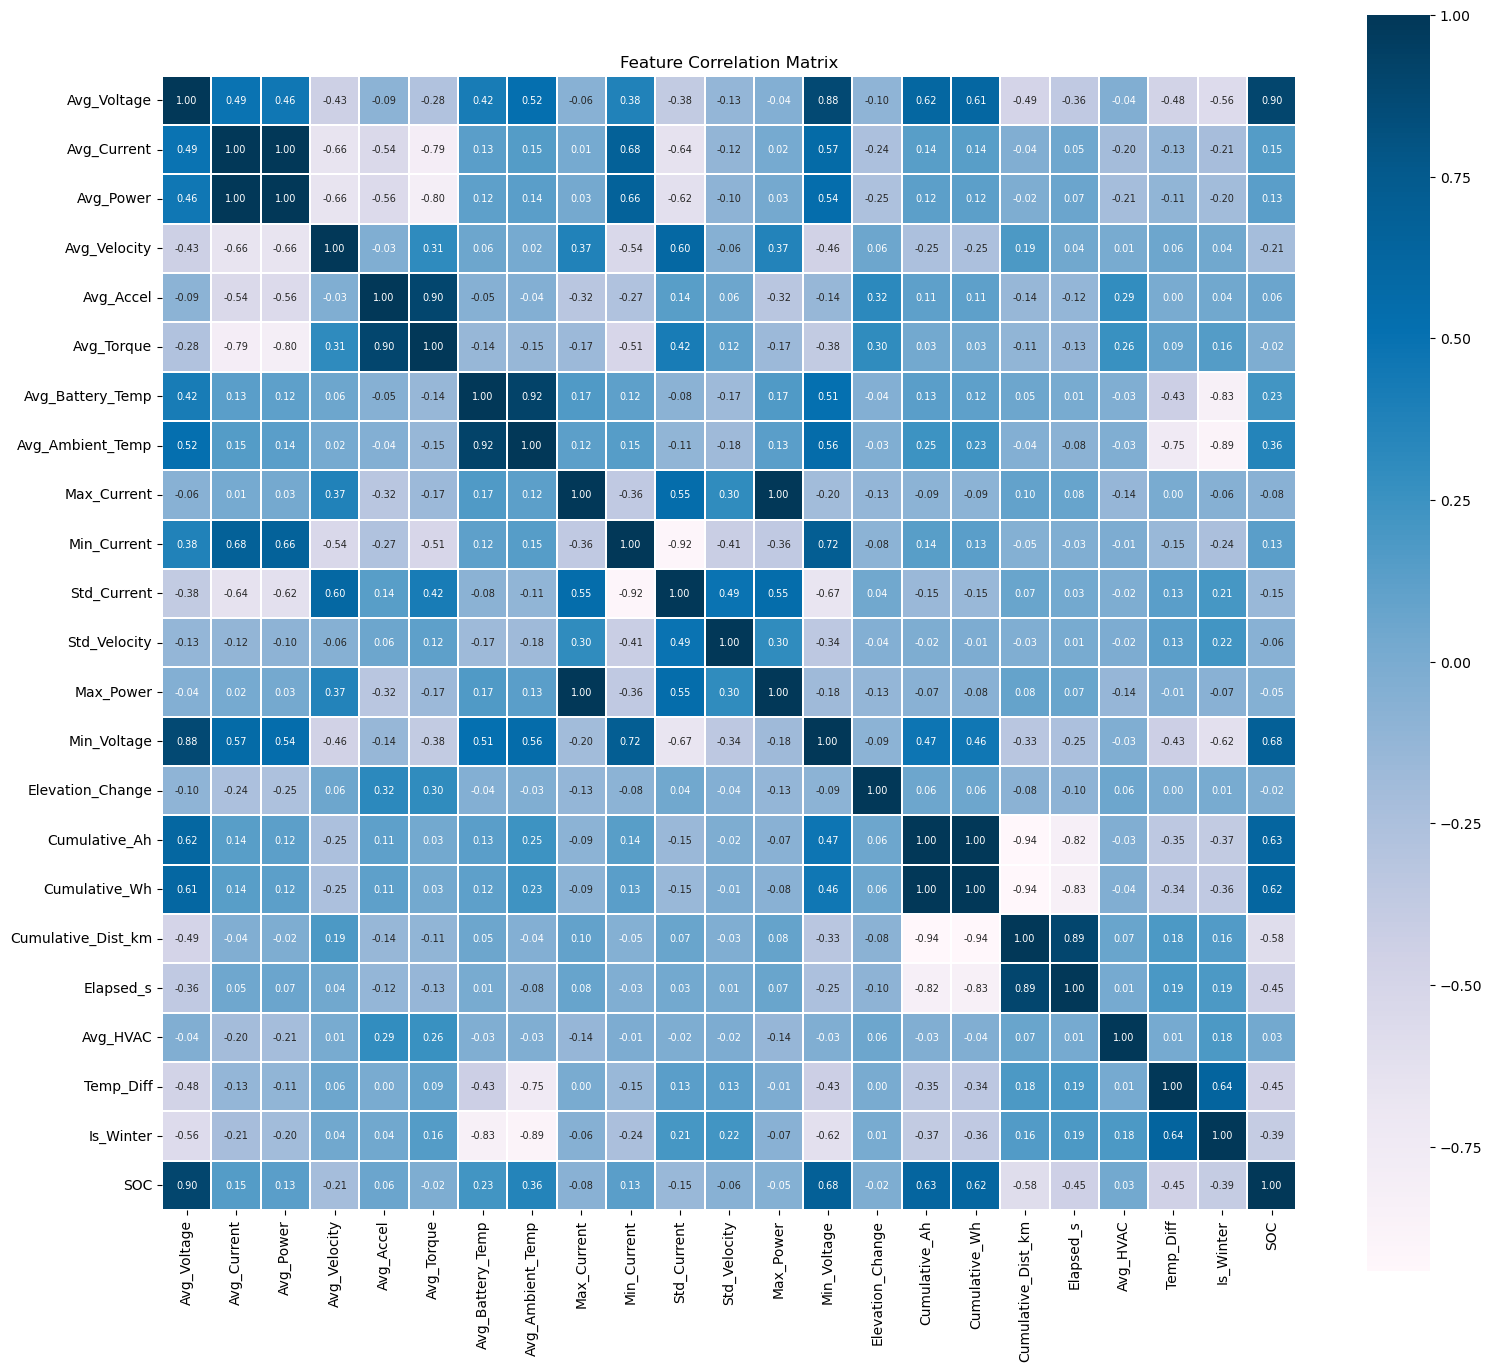


Correlation with SOC:
  Avg_Voltage             +0.8979  ++++++++++++++++++++++++++
  Min_Voltage             +0.6830  ++++++++++++++++++++
  Cumulative_Ah           +0.6334  +++++++++++++++++++
  Cumulative_Wh           +0.6228  ++++++++++++++++++
  Avg_Ambient_Temp        +0.3603  ++++++++++
  Avg_Battery_Temp        +0.2254  ++++++
  Avg_Current             +0.1532  ++++
  Min_Current             +0.1338  ++++
  Avg_Power               +0.1296  +++
  Avg_Accel               +0.0625  +
  Avg_HVAC                +0.0293  
  Avg_Torque              -0.0202  
  Elevation_Change        -0.0225  
  Max_Power               -0.0539  +
  Std_Velocity            -0.0648  +
  Max_Current             -0.0757  ++
  Std_Current             -0.1456  ++++
  Avg_Velocity            -0.2106  ++++++
  Is_Winter               -0.3935  +++++++++++
  Elapsed_s               -0.4472  +++++++++++++
  Temp_Diff               -0.4502  +++++++++++++
  Cumulative_Dist_km      -0.5782  +++++++++++++++++


In [57]:
# Clean data and inspect feature correlations with target
data_clean = data.dropna().copy()
feature_cols = [c for c in data_clean.columns if c not in ['SOC', 'Trip']]

print(f"Clean samples: {len(data_clean):,}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"\nTarget (SOC) stats:")
print(data_clean['SOC'].describe().round(2))

# Correlation heatmap
cor = data_clean[feature_cols + ['SOC']].corr()
plt.figure(figsize=(16, 14))
sns.heatmap(cor, annot=True, fmt='.2f', cmap='PuBu', square=True,
            linewidths=0.3, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation with target
cor_target = cor['SOC'].drop('SOC').sort_values(ascending=False)
print(f"\nCorrelation with SOC:")
for feat, val in cor_target.items():
    bar = '+' * int(abs(val) * 30)
    print(f"  {feat:<22s}  {val:+.4f}  {bar}")

In [58]:
# Train/test split BY TRIP (prevents data leakage)
trips = data_clean['Trip'].unique()
train_trips, test_trips = train_test_split(trips, test_size=0.25, random_state=42)

train = data_clean[data_clean['Trip'].isin(train_trips)]
test  = data_clean[data_clean['Trip'].isin(test_trips)]

X_train = train[feature_cols].values
y_train = train['SOC'].values
X_test  = test[feature_cols].values
y_test  = test['SOC'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(train_trips)} trips, {len(train):,} samples")
print(f"Test:  {len(test_trips)} trips, {len(test):,} samples")
print(f"Train SOC: {y_train.min():.1f}% - {y_train.max():.1f}% (mean {y_train.mean():.1f}%)")
print(f"Test  SOC: {y_test.min():.1f}% - {y_test.max():.1f}% (mean {y_test.mean():.1f}%)")

Train: 31 trips, 2,348 samples
Test:  11 trips, 828 samples
Train SOC: 34.6% - 88.4% (mean 70.1%)
Test  SOC: 34.3% - 85.9% (mean 68.8%)


## Model Training & Optimization
Three rounds: R1 benchmarks 9 models, R2 tunes XGBoost/LightGBM + ensembles, R3 adds polynomial features and stacking.

In [59]:
# === ROUND 1: Benchmark 9 models ===
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=5000),
    'KNN': KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=100, epsilon=0.5),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=42),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(128, 64, 32), max_iter=500,
        early_stopping=True, validation_fraction=0.15,
        learning_rate='adaptive', random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_s, y_train)

    y_pred_train = model.predict(X_train_s)
    y_pred_test  = model.predict(X_test_s)

    train_r2  = r2_score(y_train, y_pred_train)
    test_r2   = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae  = mean_absolute_error(y_test, y_pred_test)

    results[name] = {
        'Train R2': train_r2, 'Test R2': test_r2,
        'Test RMSE (%)': test_rmse, 'Test MAE (%)': test_mae,
        'Overfit': train_r2 - test_r2,
    }
    predictions[name] = y_pred_test
    print(f"R2={test_r2:.4f}, MAE={test_mae:.3f}%")

results_df = pd.DataFrame(results).T.sort_values('Test R2', ascending=False)
print("\n" + "=" * 85)
print(results_df.round(4).to_string())
print("=" * 85)

Training Ridge... R2=0.9593, MAE=2.102%
Training Lasso... R2=0.9669, MAE=1.958%
Training KNN... R2=0.6372, MAE=6.507%
Training SVR... R2=0.8840, MAE=3.054%
Training Random Forest... R2=0.6576, MAE=5.549%
Training Extra Trees... R2=0.5788, MAE=6.140%
Training Gradient Boosting... R2=0.8262, MAE=3.626%
Training AdaBoost... R2=0.7617, MAE=4.717%
Training MLP... R2=0.8933, MAE=2.900%

                   Train R2  Test R2  Test RMSE (%)  Test MAE (%)  Overfit
Lasso                0.9530   0.9669         2.5227        1.9583  -0.0138
Ridge                0.9651   0.9593         2.7981        2.1023   0.0059
MLP                  0.9963   0.8933         4.5284        2.9002   0.1030
SVR                  0.9989   0.8840         4.7228        3.0539   0.1149
Gradient Boosting    0.9994   0.8262         5.7801        3.6261   0.1732
AdaBoost             0.9118   0.7617         6.7682        4.7167   0.1501
Random Forest        0.9917   0.6576         8.1139        5.5488   0.3341
KNN             

In [60]:
# === ROUND 2: Hyperparameter tuning (XGBoost, LightGBM) + Ensemble ===
import xgboost as xgb
import lightgbm as lgbm

train_groups = train['Trip'].values
gkf = GroupKFold(n_splits=5)

print(f"Tuning on {X_train_s.shape[1]} features, {len(np.unique(train_groups))} trip groups")

Tuning on 22 features, 31 trip groups


In [61]:
# --- XGBoost tuning ---
print("Tuning XGBoost (150 iterations)...")
xgb_param_dist = {
    'n_estimators': randint(200, 1000),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.4, 0.6),
    'min_child_weight': randint(3, 30),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.5, 5),
    'gamma': uniform(0, 0.5),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    xgb_param_dist, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_s, y_train, groups=train_groups)
xgb_best = xgb_search.best_estimator_

y_pred_xgb_train = xgb_best.predict(X_train_s)
y_pred_xgb_test  = xgb_best.predict(X_test_s)

print(f"  CV R2:    {xgb_search.best_score_:.4f}")
print(f"  Train R2: {r2_score(y_train, y_pred_xgb_train):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_xgb_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_xgb_test):.3f}%")

Tuning XGBoost (150 iterations)...
  CV R2:    0.8432
  Train R2: 0.9983
  Test R2:  0.8718
  Test MAE: 3.192%


In [62]:
# --- LightGBM tuning ---
print("Tuning LightGBM (150 iterations)...")
lgb_param_dist = {
    'n_estimators': randint(200, 1000),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.4, 0.6),
    'min_child_samples': randint(5, 50),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.5, 5),
    'num_leaves': randint(15, 100),
}

lgb_search = RandomizedSearchCV(
    lgbm.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgb_param_dist, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
lgb_search.fit(X_train_s, y_train, groups=train_groups)
lgb_best = lgb_search.best_estimator_

y_pred_lgb_train = lgb_best.predict(X_train_s)
y_pred_lgb_test  = lgb_best.predict(X_test_s)

print(f"  CV R2:    {lgb_search.best_score_:.4f}")
print(f"  Train R2: {r2_score(y_train, y_pred_lgb_train):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_lgb_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_lgb_test):.3f}%")

Tuning LightGBM (150 iterations)...
  CV R2:    0.8295
  Train R2: 0.9960
  Test R2:  0.8654
  Test MAE: 3.257%


In [63]:
# --- Ensemble: R1 Best + XGBoost + LightGBM ---
from sklearn.model_selection import cross_val_predict
from scipy.optimize import minimize

r1_best_name  = results_df.index[0]
r1_best_model = models[r1_best_name]
print(f"R1 best: {r1_best_name}")

base = {'XGBoost': xgb_best, 'LightGBM': lgb_best, r1_best_name: r1_best_model}

oof_preds  = {}
test_preds = {}
for name, mdl in base.items():
    oof = cross_val_predict(mdl, X_train_s, y_train, cv=gkf,
                            groups=train_groups, n_jobs=-1)
    oof_preds[name] = oof
    mdl.fit(X_train_s, y_train)
    test_preds[name] = mdl.predict(X_test_s)
    print(f"  {name}: OOF R2={r2_score(y_train, oof):.4f}")

oof_mat  = np.column_stack(list(oof_preds.values()))
test_mat = np.column_stack(list(test_preds.values()))

def obj(w):
    return np.mean((y_train - oof_mat @ w) ** 2)

n_base = len(base)
res = minimize(obj, x0=np.ones(n_base) / n_base, method='SLSQP',
               bounds=[(0, 1)] * n_base,
               constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})
weights = res.x
print(f"\nOptimal weights: {dict(zip(base.keys(), weights.round(3)))}")

y_pred_ens_train = oof_mat @ weights
y_pred_ens_test  = test_mat @ weights
print(f"\nWeighted Ensemble:  Test R2={r2_score(y_test, y_pred_ens_test):.4f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_ens_test):.3f}%")

y_pred_avg_train = oof_mat.mean(axis=1)
y_pred_avg_test  = test_mat.mean(axis=1)
print(f"Averaging Ensemble: Test R2={r2_score(y_test, y_pred_avg_test):.4f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_avg_test):.3f}%")

R1 best: Lasso
  XGBoost: OOF R2=0.8808
  LightGBM: OOF R2=0.8754
  Lasso: OOF R2=0.9223

Optimal weights: {'XGBoost': np.float64(0.321), 'LightGBM': np.float64(0.0), 'Lasso': np.float64(0.679)}

Weighted Ensemble:  Test R2=0.9496  MAE=2.201%
Averaging Ensemble: Test R2=0.9157  MAE=2.643%


In [64]:
# === ROUND 3: Polynomial features + ElasticNet + Stacking ===
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.model_selection import KFold

# --- 3a: Build degree-2 polynomial interactions on top features ---
# Physics: OCV-SOC curve is nonlinear at extremes; voltage shifts with temperature
top_feats = ['Avg_Voltage', 'Min_Voltage', 'Avg_Current', 'Cumulative_Ah',
             'Cumulative_Wh', 'Avg_Battery_Temp', 'Temp_Diff', 'Avg_Power',
             'Cumulative_Dist_km', 'Elapsed_s']
top_idx = [feature_cols.index(f) for f in top_feats]

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s[:, top_idx])
X_test_poly  = poly.transform(X_test_s[:, top_idx])
print(f"Poly features: {X_train_poly.shape[1]} (from {len(top_feats)} base features)")

# --- 3b: Lasso on poly features ---
lasso_poly = LassoCV(alphas=np.logspace(-5, 1, 50), cv=5, max_iter=10000, random_state=42)
lasso_poly.fit(X_train_poly, y_train)
y_pred_lp_train = lasso_poly.predict(X_train_poly)
y_pred_lp_test  = lasso_poly.predict(X_test_poly)
print(f"\nLasso Poly:    Test R2={r2_score(y_test, y_pred_lp_test):.4f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_lp_test):.3f}%  "
      f"alpha={lasso_poly.alpha_:.5f}  "
      f"non-zero={np.sum(lasso_poly.coef_ != 0)}/{len(lasso_poly.coef_)}")

# --- 3c: Ridge on poly features ---
ridge_poly = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_poly.fit(X_train_poly, y_train)
y_pred_rp_train = ridge_poly.predict(X_train_poly)
y_pred_rp_test  = ridge_poly.predict(X_test_poly)
print(f"Ridge Poly:    Test R2={r2_score(y_test, y_pred_rp_test):.4f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_rp_test):.3f}%  "
      f"alpha={ridge_poly.alpha_:.3f}")

# --- 3d: ElasticNet on poly features ---
enet_poly = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                         alphas=np.logspace(-5, 1, 30),
                         cv=5, max_iter=10000, random_state=42)
enet_poly.fit(X_train_poly, y_train)
y_pred_ep_train = enet_poly.predict(X_train_poly)
y_pred_ep_test  = enet_poly.predict(X_test_poly)
print(f"ElasticNet:    Test R2={r2_score(y_test, y_pred_ep_test):.4f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_ep_test):.3f}%  "
      f"alpha={enet_poly.alpha_:.5f}  l1_ratio={enet_poly.l1_ratio_:.1f}")

# --- 3e: Stacking — OOF preds from R2 + LassoPoly → Ridge meta ---
stack_train = oof_mat.copy()
stack_test  = test_mat.copy()

# Generate Lasso-poly OOF for diversity
lp_oof = np.zeros(len(y_train))
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, val_idx in kf5.split(X_train_poly):
    lp_fold = LassoCV(alphas=np.logspace(-5, 1, 30), cv=3, max_iter=10000, random_state=42)
    lp_fold.fit(X_train_poly[tr_idx], y_train[tr_idx])
    lp_oof[val_idx] = lp_fold.predict(X_train_poly[val_idx])

stack_train = np.column_stack([stack_train, lp_oof])
stack_test  = np.column_stack([stack_test, lasso_poly.predict(X_test_poly)])

meta = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
meta.fit(stack_train, y_train)
y_pred_stack_train = meta.predict(stack_train)
y_pred_stack_test  = meta.predict(stack_test)
base_names = list(base.keys()) + ['LassoPoly']
print(f"\nStacking (Ridge meta): Test R2={r2_score(y_test, y_pred_stack_test):.4f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_stack_test):.3f}%")
print(f"  Meta weights: {dict(zip(base_names, meta.coef_.round(4)))}")

# Collect R3 results
round3 = {}
r3_preds = {
    'Lasso Poly':        (y_pred_lp_train, y_pred_lp_test),
    'Ridge Poly':        (y_pred_rp_train, y_pred_rp_test),
    'ElasticNet Poly':   (y_pred_ep_train, y_pred_ep_test),
    'Stacking (Ridge)':  (y_pred_stack_train, y_pred_stack_test),
}
print(f"\n--- Round 3 Summary ---")
for name, (ytr, yte) in r3_preds.items():
    tr_r2 = r2_score(y_train, ytr)
    te_r2 = r2_score(y_test, yte)
    round3[name] = {
        'Train R2': tr_r2, 'Test R2': te_r2,
        'Test RMSE (%)': np.sqrt(mean_squared_error(y_test, yte)),
        'Test MAE (%)': mean_absolute_error(y_test, yte),
        'Overfit': tr_r2 - te_r2,
    }
    print(f"  {name:<20s}  R2={te_r2:.4f}  MAE={mean_absolute_error(y_test, yte):.3f}%  Overfit={tr_r2-te_r2:.4f}")

Poly features: 65 (from 10 base features)

Lasso Poly:    Test R2=0.9307  MAE=2.503%  alpha=0.01151  non-zero=39/65
Ridge Poly:    Test R2=0.9058  MAE=2.874%  alpha=4.715
ElasticNet:    Test R2=0.9234  MAE=2.640%  alpha=0.00788  l1_ratio=0.9

Stacking (Ridge meta): Test R2=0.9337  MAE=2.451%
  Meta weights: {'XGBoost': np.float64(0.1557), 'LightGBM': np.float64(-0.0547), 'Lasso': np.float64(-0.0302), 'LassoPoly': np.float64(0.9609)}

--- Round 3 Summary ---
  Lasso Poly            R2=0.9307  MAE=2.503%  Overfit=0.0482
  Ridge Poly            R2=0.9058  MAE=2.874%  Overfit=0.0751
  ElasticNet Poly       R2=0.9234  MAE=2.640%  Overfit=0.0562
  Stacking (Ridge)      R2=0.9337  MAE=2.451%  Overfit=0.0340


## Evaluation & Visualization

FULL SOC BENCHMARK  (sensor + cumulative features, trip-level split)
                    Test R2  Test MAE (%)  Test RMSE (%)  Overfit
Lasso                0.9669        1.9583         2.5227  -0.0138
Ridge                0.9593        2.1023         2.7981   0.0059
Weighted Ensemble    0.9496        2.2007         3.1119  -0.0153
Stacking (Ridge)     0.9337        2.4505         3.5707   0.0340
Lasso Poly           0.9307        2.5031         3.6494   0.0482
ElasticNet Poly      0.9234        2.6400         3.8379   0.0562
Averaging Ensemble   0.9157        2.6433         4.0261   0.0040
Ridge Poly           0.9058        2.8736         4.2566   0.0751
MLP                  0.8933        2.9002         4.5284   0.1030
SVR                  0.8840        3.0539         4.7228   0.1149
XGBoost (tuned)      0.8718        3.1919         4.9646   0.1265
LightGBM (tuned)     0.8654        3.2575         5.0868   0.1306
Gradient Boosting    0.8262        3.6261         5.7801   0.1732
AdaBoos

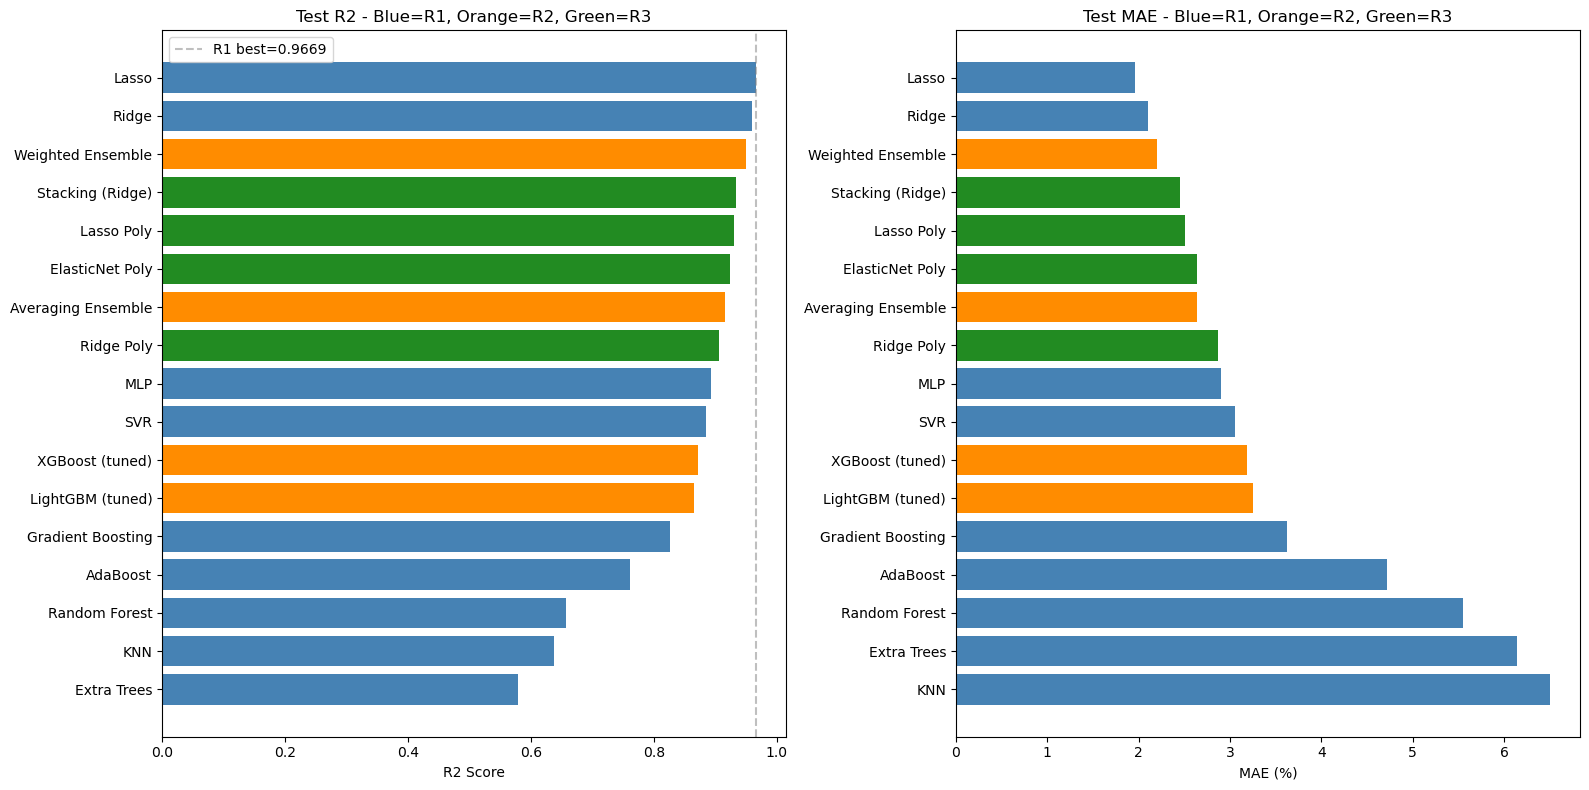

In [65]:
# --- Full comparison: Round 1 vs Round 2 vs Round 3 ---
all_results = {**results, **round2, **round3}
all_df = pd.DataFrame(all_results).T.sort_values('Test R2', ascending=False)

print("=" * 90)
print("FULL SOC BENCHMARK  (sensor + cumulative features, trip-level split)")
print("=" * 90)
print(all_df[['Test R2', 'Test MAE (%)', 'Test RMSE (%)', 'Overfit']].round(4).to_string())
print("=" * 90)

r1_best_r2        = results_df.iloc[0]['Test R2']
overall_best_name = all_df.index[0]
overall_best_r2   = all_df.iloc[0]['Test R2']
print(f"\nRound 1 best: {results_df.index[0]} (R2={r1_best_r2:.4f})")
print(f"Overall best:  {overall_best_name} (R2={overall_best_r2:.4f})")

# Track best model (for poly models, store None — they need different pipeline)
model_map = {
    'XGBoost (tuned)': xgb_best, 'LightGBM (tuned)': lgb_best,
    **{k: models[k] for k in models}
}
best_name  = overall_best_name
best_model = model_map.get(best_name)

# Also store predictions for scatter plots etc.
r2_models_all = {**r2_models, **r3_preds}

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sorted_all = all_df.sort_values('Test R2', ascending=True)
def get_color(n):
    if n in round3: return 'forestgreen'
    if n in round2: return 'darkorange'
    return 'steelblue'
colors = [get_color(n) for n in sorted_all.index]
axes[0].barh(sorted_all.index, sorted_all['Test R2'], color=colors)
axes[0].set_xlabel('R2 Score')
axes[0].set_title('Test R2 - Blue=R1, Orange=R2, Green=R3')
axes[0].axvline(r1_best_r2, color='gray', ls='--', alpha=0.5, label=f'R1 best={r1_best_r2:.4f}')
axes[0].legend()

sorted_mae = all_df.sort_values('Test MAE (%)', ascending=False)
colors_mae = [get_color(n) for n in sorted_mae.index]
axes[1].barh(sorted_mae.index, sorted_mae['Test MAE (%)'], color=colors_mae)
axes[1].set_xlabel('MAE (%)')
axes[1].set_title('Test MAE - Blue=R1, Orange=R2, Green=R3')
plt.tight_layout()
plt.show()

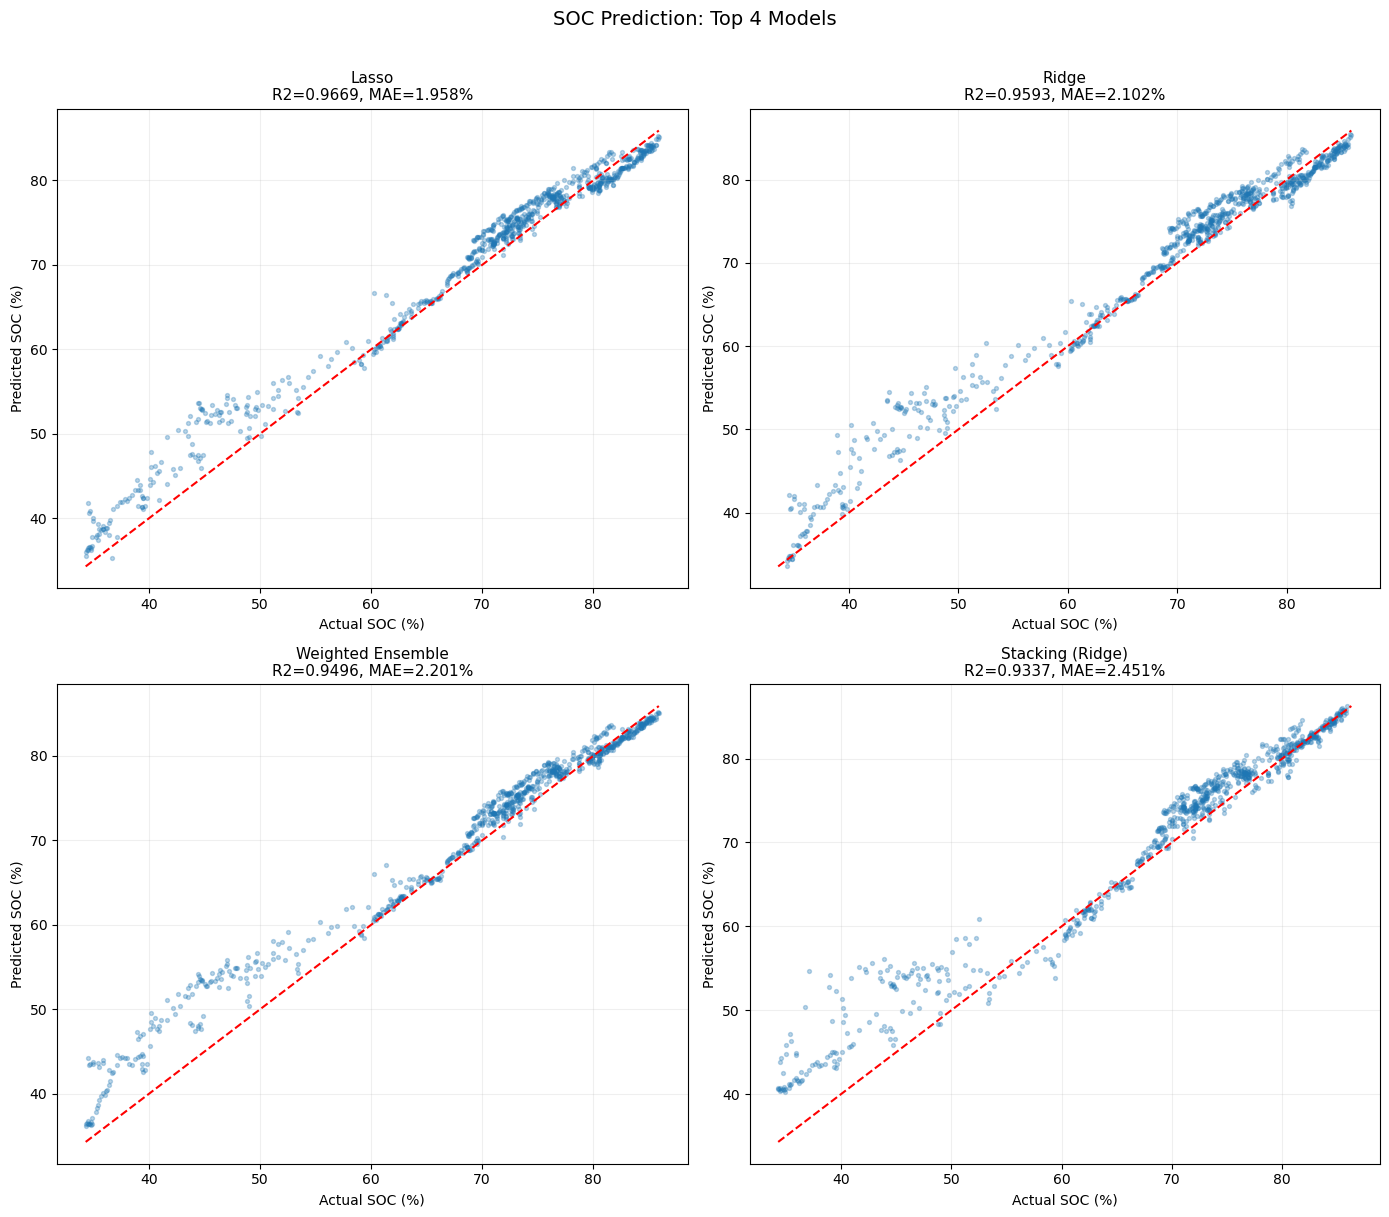

In [66]:
# Scatter plots: predicted vs actual for top 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
top4 = all_df.head(4).index.tolist()

for idx, name in enumerate(top4):
    ax = axes[idx // 2, idx % 2]
    if name in predictions:
        y_pred = predictions[name]
    elif name in r2_models_all:
        y_pred = r2_models_all[name][1]
    else:
        continue
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.3, s=8)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{name}\nR2={r2:.4f}, MAE={mae:.3f}%', fontsize=11)
    ax.set_xlabel('Actual SOC (%)')
    ax.set_ylabel('Predicted SOC (%)')
    ax.grid(True, alpha=0.2)

plt.suptitle('SOC Prediction: Top 4 Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

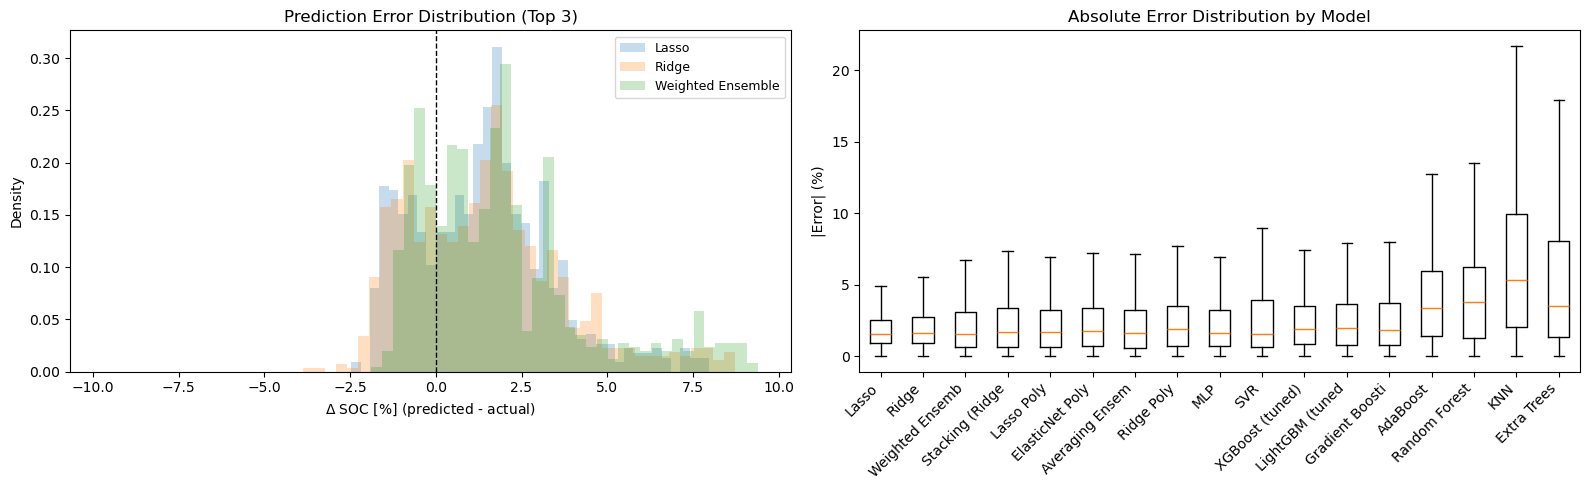

In [67]:
# Error distribution (top 3)
top3_names = all_df.head(3).index.tolist()
kwargs = dict(histtype='stepfilled', alpha=0.25, density=True, ec='k')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for name in top3_names:
    if name in predictions:
        errors = predictions[name] - y_test
    elif name in r2_models_all:
        errors = r2_models_all[name][1] - y_test
    else:
        continue
    max_err = max(3, np.percentile(np.abs(errors), 99.5))
    bins = np.arange(-max_err, max_err, max_err / 30)
    ax.hist(errors, label=name, bins=bins, **kwargs)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_xlabel('$\\Delta$ SOC [%] (predicted - actual)')
ax.set_ylabel('Density')
ax.set_title('Prediction Error Distribution (Top 3)')
ax.legend(fontsize=9)

ax2 = axes[1]
abs_errors = {}
for name in all_df.index:
    if name in predictions:
        abs_errors[name] = np.abs(predictions[name] - y_test)
    elif name in r2_models_all:
        abs_errors[name] = np.abs(r2_models_all[name][1] - y_test)
sorted_names = [n for n in all_df.index if n in abs_errors]
ax2.boxplot([abs_errors[n] for n in sorted_names],
            labels=[n[:15] for n in sorted_names],
            vert=True, showfliers=False)
ax2.set_ylabel('|Error| (%)')
ax2.set_title('Absolute Error Distribution by Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

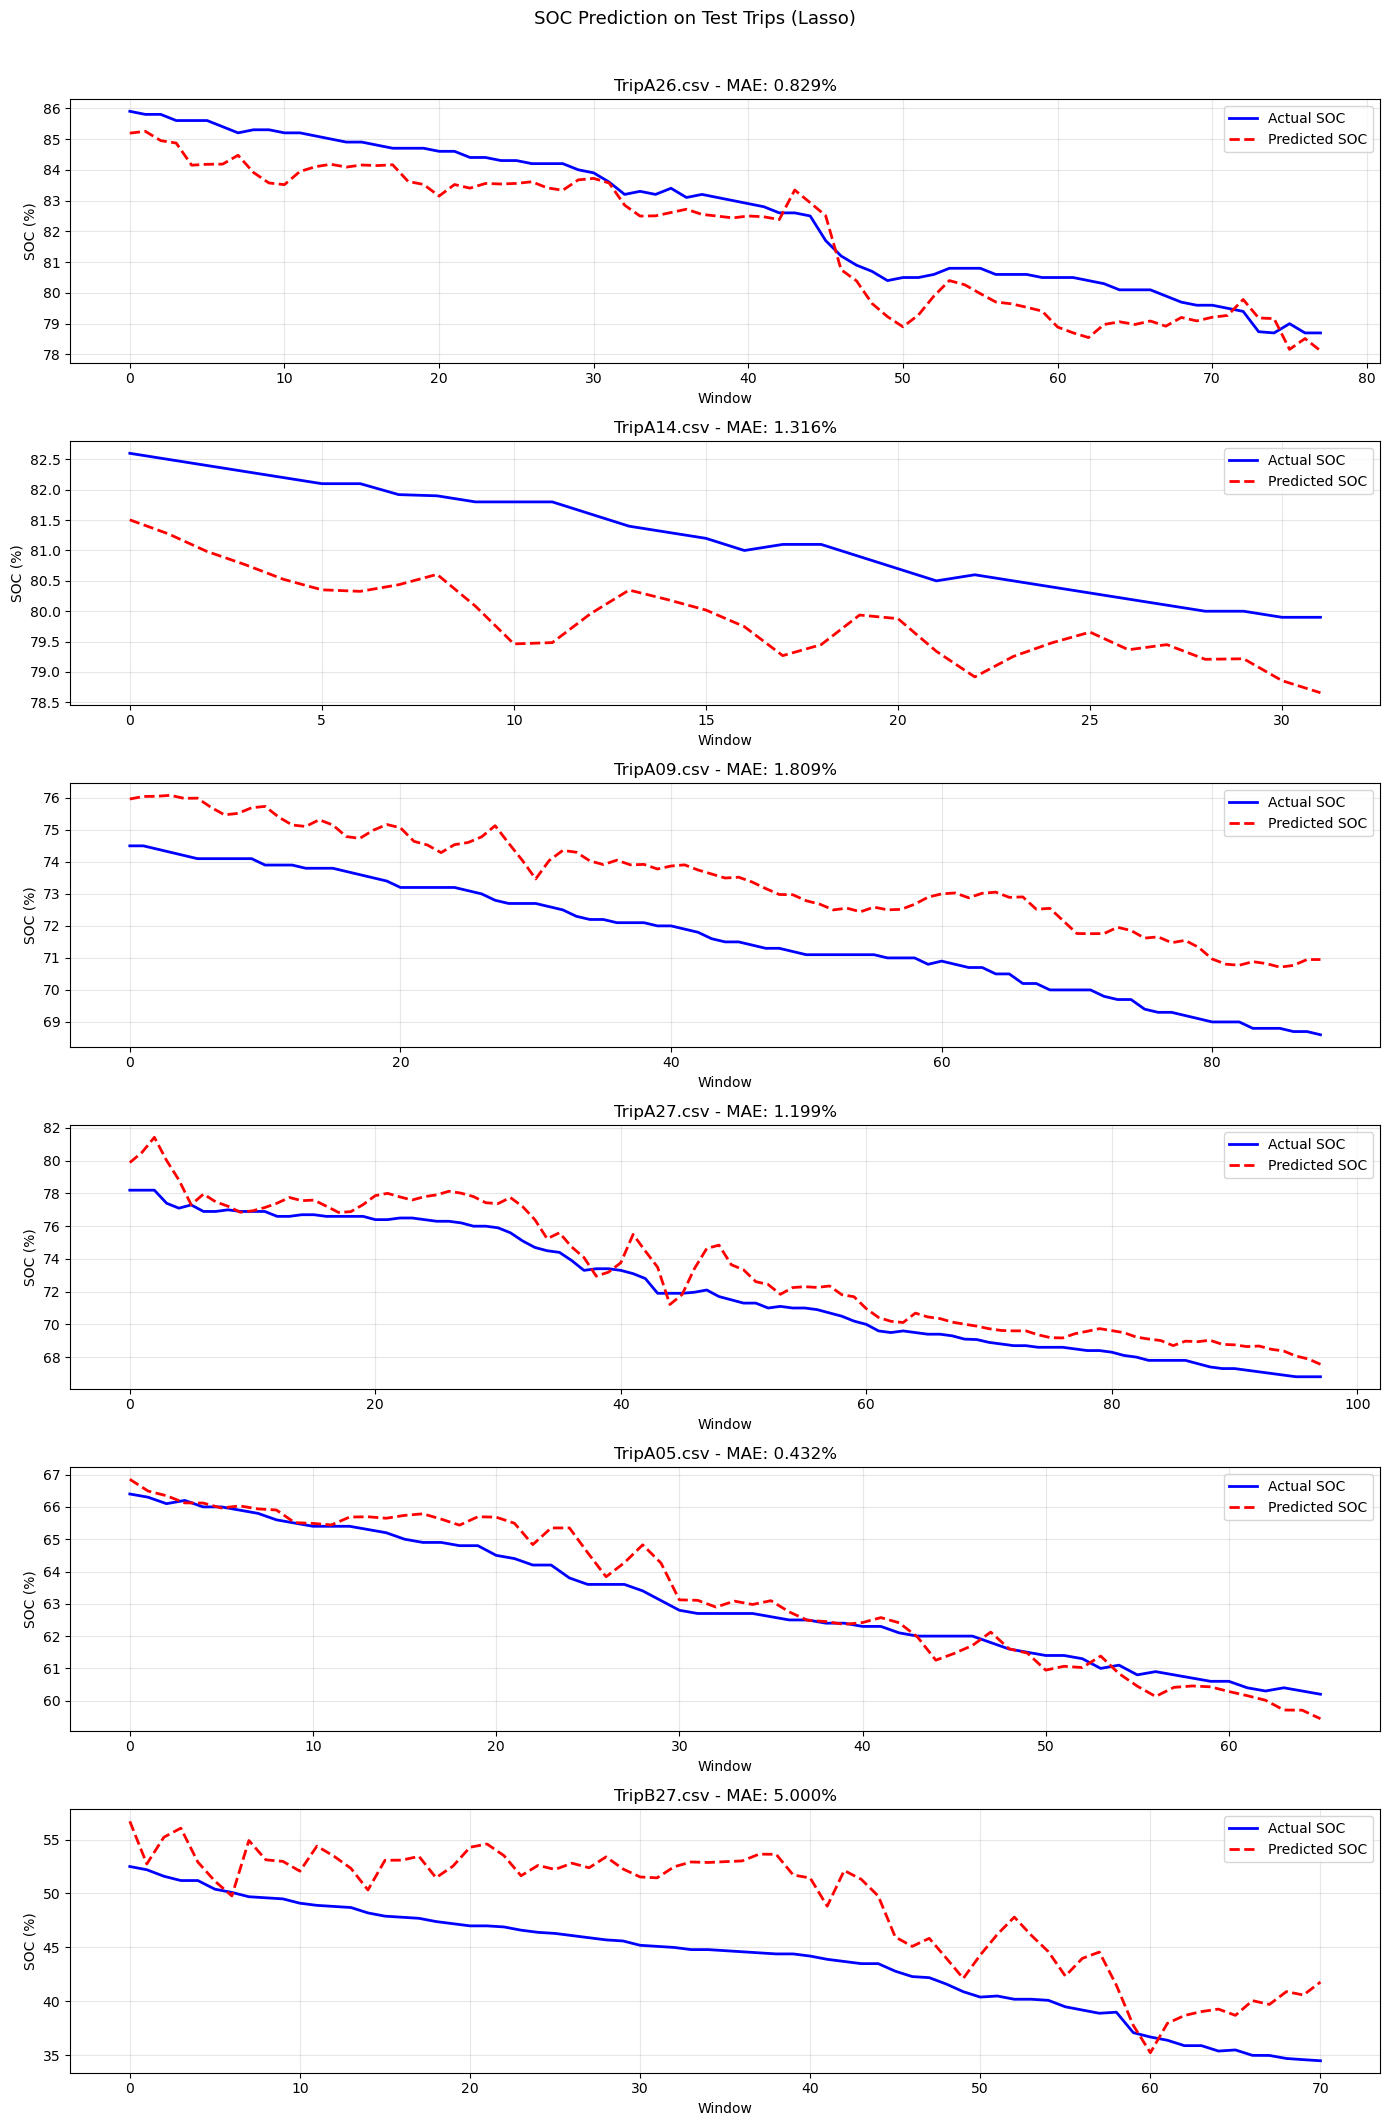

In [68]:
# SOC prediction on test trips - actual vs predicted over time
# For poly models, we need special handling; for standard models use best_model
# Pick best usable model for per-trip prediction
if best_model is not None:
    plot_model_name = best_name
    def predict_trip(trip_features):
        return best_model.predict(scaler.transform(trip_features))
elif best_name in round3:
    # Poly model — need poly transform pipeline
    plot_model_name = best_name
    def predict_trip(trip_features):
        X_s = scaler.transform(trip_features)
        X_p = poly.transform(X_s[:, top_idx])
        if 'Lasso' in best_name:
            return lasso_poly.predict(X_p)
        elif 'Ridge' in best_name and 'Stacking' not in best_name:
            return ridge_poly.predict(X_p)
        else:
            return enet_poly.predict(X_p)
else:
    # Fallback to Lasso (R1 best)
    plot_model_name = 'Lasso'
    lasso_fb = models['Lasso']
    def predict_trip(trip_features):
        return lasso_fb.predict(scaler.transform(trip_features))

n_trips_plot = min(len(test_trips), 6)
fig, axes = plt.subplots(n_trips_plot, 1,
                         figsize=(14, 3.5 * n_trips_plot), squeeze=False)

for t_idx, trip in enumerate(test_trips[:n_trips_plot]):
    trip_data = test[test['Trip'] == trip].reset_index(drop=True)
    if len(trip_data) < 3:
        continue

    pred_soc   = predict_trip(trip_data[feature_cols].values)
    actual_soc = trip_data['SOC'].values

    ax = axes[t_idx, 0]
    x = range(len(actual_soc))
    ax.plot(x, actual_soc, 'b-', linewidth=2, label='Actual SOC')
    ax.plot(x, pred_soc, 'r--', linewidth=2, label='Predicted SOC')
    mae = mean_absolute_error(actual_soc, pred_soc)
    ax.set_title(f'{trip} - MAE: {mae:.3f}%')
    ax.set_xlabel('Window')
    ax.set_ylabel('SOC (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'SOC Prediction on Test Trips ({plot_model_name})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Summary & Feature Importance

In [69]:
# Final summary
print("=" * 70)
print("SOC PREDICTION BENCHMARK SUMMARY")
print("=" * 70)
print(f"\nApproach: Window-based SOC estimation (no Prev_SOC leak)")
print(f"Window: {WINDOW} samples ({WINDOW//10}s), Stride: {STRIDE} ({STRIDE//10}s)")
print(f"Dataset: {len(data_clean):,} windows from {data_clean['Trip'].nunique()} trips")
print(f"Features: {len(feature_cols)} base + {X_train_poly.shape[1]} poly (R3)")
print(f"Train/Test split: {len(train_trips)}/{len(test_trips)} trips")
print(f"\nAll Models (by Test R2):")
for i, (name, row) in enumerate(all_df.iterrows(), 1):
    if name in round3:
        src = "R3"
    elif name in round2:
        src = "R2"
    else:
        src = "R1"
    marker = " < BEST" if i == 1 else ""
    print(f"  {i:2d}. [{src}] {name:<22s}  R2={row['Test R2']:.4f}  "
          f"MAE={row['Test MAE (%)']:.3f}%  "
          f"RMSE={row['Test RMSE (%)']:.3f}%  "
          f"Overfit={row['Overfit']:.4f}{marker}")

best_row = all_df.iloc[0]
print(f"\nBest: {all_df.index[0]} -- R2={best_row['Test R2']:.4f}, "
      f"MAE={best_row['Test MAE (%)']:.3f}%")
print("=" * 70)

SOC PREDICTION BENCHMARK SUMMARY

Approach: Window-based SOC estimation (no Prev_SOC leak)
Window: 600 samples (60s), Stride: 200 (20s)
Dataset: 3,176 windows from 42 trips
Features: 22 base + 65 poly (R3)
Train/Test split: 31/11 trips

All Models (by Test R2):
   1. [R1] Lasso                   R2=0.9669  MAE=1.958%  RMSE=2.523%  Overfit=-0.0138 < BEST
   2. [R1] Ridge                   R2=0.9593  MAE=2.102%  RMSE=2.798%  Overfit=0.0059
   3. [R2] Weighted Ensemble       R2=0.9496  MAE=2.201%  RMSE=3.112%  Overfit=-0.0153
   4. [R3] Stacking (Ridge)        R2=0.9337  MAE=2.451%  RMSE=3.571%  Overfit=0.0340
   5. [R3] Lasso Poly              R2=0.9307  MAE=2.503%  RMSE=3.649%  Overfit=0.0482
   6. [R3] ElasticNet Poly         R2=0.9234  MAE=2.640%  RMSE=3.838%  Overfit=0.0562
   7. [R2] Averaging Ensemble      R2=0.9157  MAE=2.643%  RMSE=4.026%  Overfit=0.0040
   8. [R3] Ridge Poly              R2=0.9058  MAE=2.874%  RMSE=4.257%  Overfit=0.0751
   9. [R1] MLP                     R2=0.8

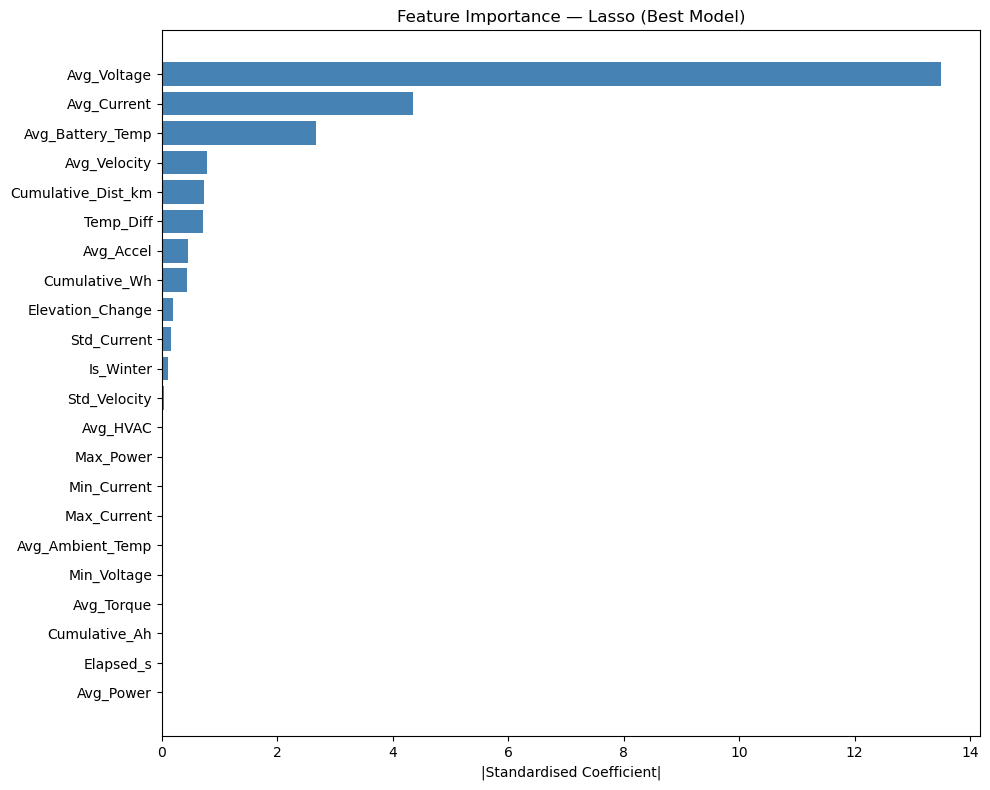

Top 5 features (Lasso):
  Avg_Voltage: 13.4977
  Avg_Current: 4.3432
  Avg_Battery_Temp: 2.6745
  Avg_Velocity: 0.7818
  Cumulative_Dist_km: 0.7268


In [70]:
# Feature importance for best model (Lasso — standardised coefficients)
coefs = pd.Series(np.abs(models['Lasso'].coef_), index=feature_cols, name='|Coef|')
coefs = coefs.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coefs.index, coefs.values, color='steelblue')
ax.set_xlabel('|Standardised Coefficient|')
ax.set_title(f'Feature Importance — {best_name} (Best Model)')
plt.tight_layout()
plt.show()

print(f"Top 5 features ({best_name}):")
for feat, val in coefs.nlargest(5).items():
    print(f"  {feat}: {val:.4f}")